# Ising Spin-Chain Variants

**Model.** This notebook compares the transverse-field Ising chain, a longitudinal-field variant, and a next-nearest-neighbor Ising chain. These are dense qubit-space Hamiltonians with dimension `2**n_sites`.

**Typical uses.** Small-system exact diagonalization, spectral-gap checks, symmetry-breaking examples, frustrated-chain toy models, and reference problems for variational or phase-estimation workflows.

**Parameters.** `n_sites` is the number of spins; `j`, `j1`, and `j2` set `ZZ` couplings; `h` or `h_x` sets the transverse `X` field; `h_z` sets a longitudinal `Z` field; `periodic` controls boundary conditions.

**Useful plots.** Sorted spectra, gap-versus-field curves, and density-of-states histograms.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from quantum_lattice_models.models import (
    longitudinal_field_ising,
    next_nearest_neighbor_ising,
    transverse_field_ising,
)
from quantum_lattice_models.plotting import plot_lattice_spectrum
from quantum_lattice_models.spectra import ground_energy, spectral_gap

In [2]:
n_sites = 5
models = {
    "TFIM": transverse_field_ising(n_sites=n_sites, j=1.0, h=0.7),
    "Longitudinal": longitudinal_field_ising(n_sites=n_sites, j=1.0, h_x=0.7, h_z=0.2),
    "NNN Ising": next_nearest_neighbor_ising(n_sites=n_sites, j1=1.0, j2=0.35, h=0.7),
}

print("model        | shape    | ground energy | spectral gap")
print("---          | ---      | ---           | ---")
for name, H in models.items():
    print(f"{name:<12s} | {str(H.shape):<8s} | {ground_energy(H): .6f}    | {spectral_gap(H): .6f}")

model        | shape    | ground energy | spectral gap
---          | ---      | ---           | ---
TFIM         | (32, 32) | -4.971328    |  0.183511
Longitudinal | (32, 32) | -5.749750    |  1.608582
NNN Ising    | (32, 32) | -5.752421    |  0.070473


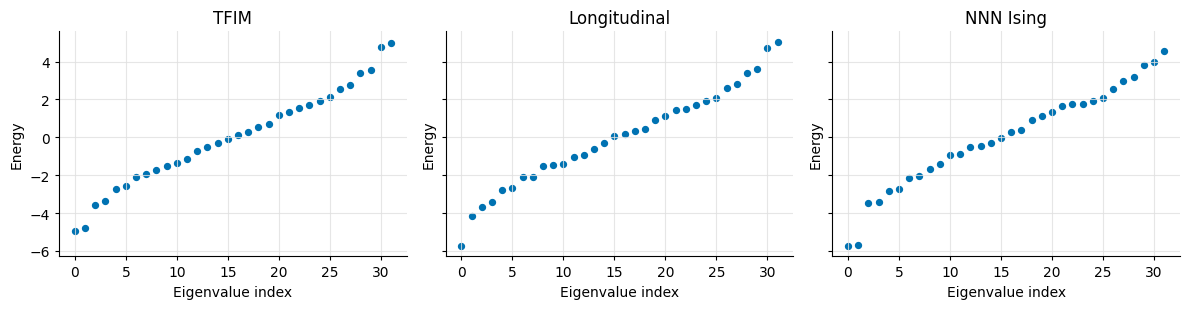

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.2), sharey=True)
for ax, (name, H) in zip(axes, models.items(), strict=False):
    plot_lattice_spectrum(H, ax=ax, s=18)
    ax.set_title(name)
fig.tight_layout()

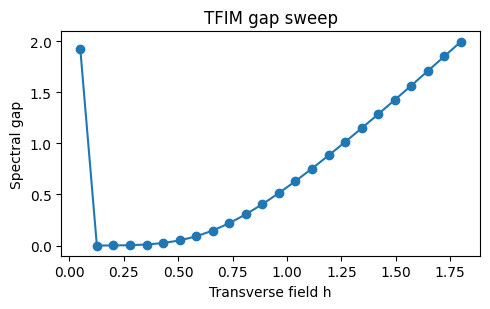

In [4]:
fields = np.linspace(0.05, 1.8, 24)
gaps = [spectral_gap(transverse_field_ising(n_sites=5, j=1.0, h=float(h))) for h in fields]

fig, ax = plt.subplots(figsize=(5, 3.2))
ax.plot(fields, gaps, marker="o")
ax.set_xlabel("Transverse field h")
ax.set_ylabel("Spectral gap")
ax.set_title("TFIM gap sweep")
fig.tight_layout()